# 📊 NOTEBOOK 1 - EDA (PROFESSIONAL VERSION)
***📌 Load Data***

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\user\OneDrive\Documents\Data_Science_Freelancing_sample_projects\student__data.csv")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


***📌 Clean Column Names***

In [2]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()

,marital_status,application_mode,application_order,course,daytime/evening_attendance,previous_qualification,nacionality,mother's_qualification,father's_qualification,mother's_occupation,...,curricular_units_2nd_sem_(credited),curricular_units_2nd_sem_(enrolled),curricular_units_2nd_sem_(evaluations),curricular_units_2nd_sem_(approved),curricular_units_2nd_sem_(grade),curricular_units_2nd_sem_(without_evaluations),unemployment_rate,inflation_rate,gdp,target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


***📌 Target Analysis***

Text(0.5, 1.0, 'Student Outcome Distribution')

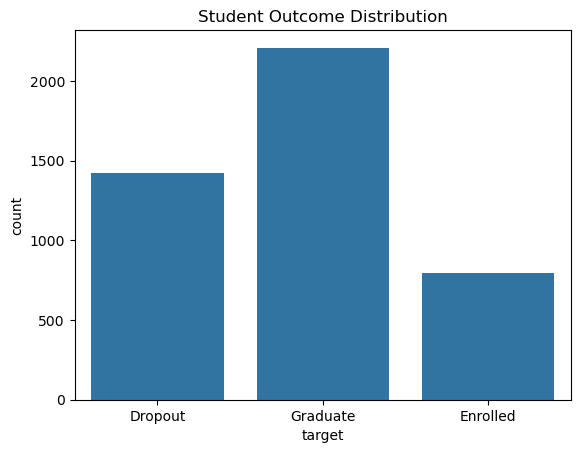

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.title("Student Outcome Distribution")

***📌 Academic Performance Insight***

Text(0.5, 1.0, 'Grade Distribution')

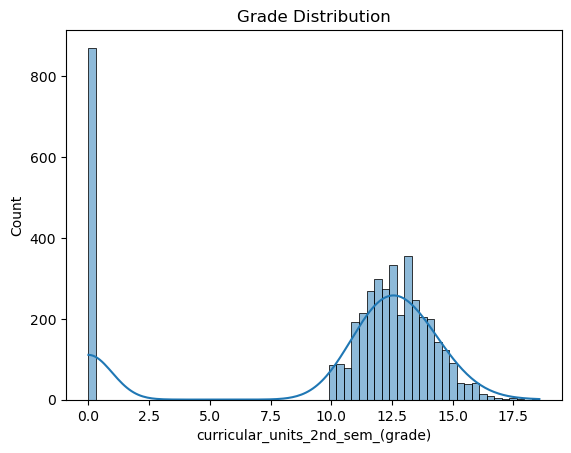

In [4]:
sns.histplot(df['curricular_units_2nd_sem_(grade)'], kde=True)
plt.title("Grade Distribution")

***📌 Key Relationship Analysis***

<Axes: xlabel='curricular_units_2nd_sem_(approved)', ylabel='curricular_units_2nd_sem_(grade)'>

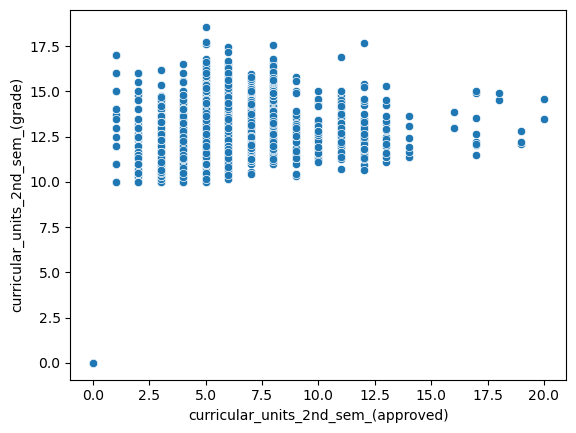

In [5]:
sns.scatterplot(
    x='curricular_units_2nd_sem_(approved)',
    y='curricular_units_2nd_sem_(grade)',
    data=df
)

***📌 Correlation Heatmap***

<Axes: >

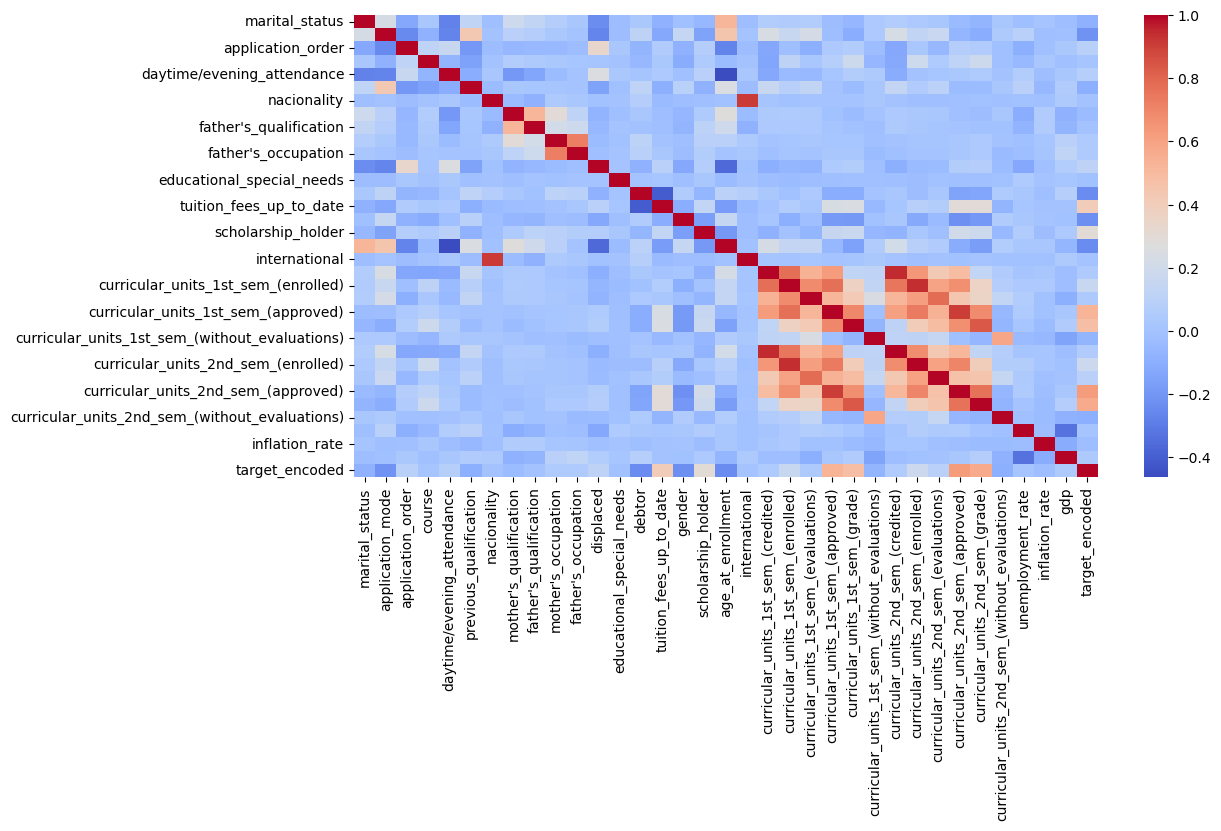

In [6]:
df['target_encoded'] = df['target'].map({
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
})

corr = df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(corr, cmap='coolwarm')

****📊 ROI by Course****

In [11]:
roi = df.groupby('course')['target'].apply(lambda x: (x == 'Graduate').mean())

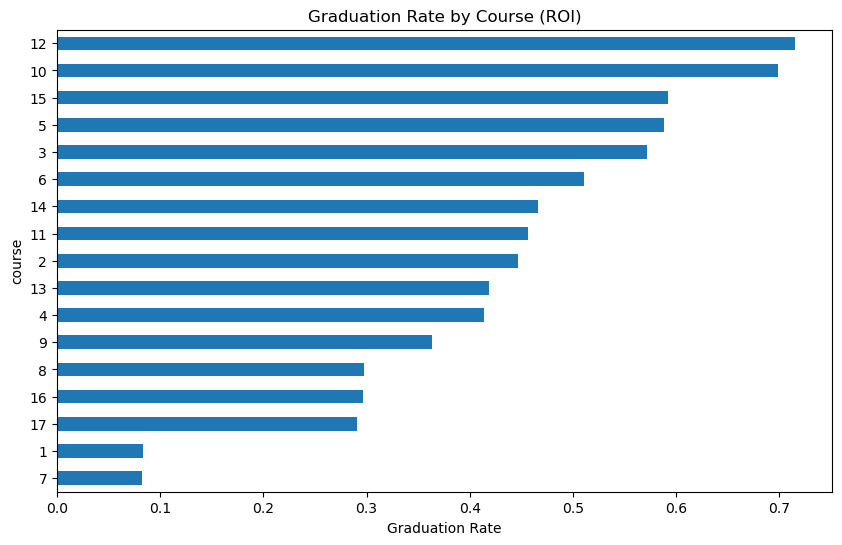

In [12]:
import matplotlib.pyplot as plt

roi.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Graduation Rate by Course (ROI)")
plt.xlabel("Graduation Rate")
plt.show()